<a href="https://colab.research.google.com/github/Thalapathi26/AI_ML/blob/main/unsupervise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/fitness_dataset.csv')
df.head()

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,bmi,heart_rate_resting,heart_rate_avg,calories_burned,consistency_score,lifestyle_category,fitness_level
0,56,12633,122,1084,8.65,8.67,4.42,2,5.61,2.14,16.00,54.8,103.0,1500.0,3.84,Active,Moderate
1,46,1980,33,1122,5.97,5.37,7.91,2,8.17,0.92,37.07,75.2,126.3,1500.0,7.25,Active,Unfit
2,32,7139,60,1049,6.23,7.15,4.20,0,3.47,2.67,27.36,66.3,101.4,1500.0,5.77,Sedentary,Unfit
3,60,4814,66,1018,5.09,7.61,7.12,4,5.26,2.17,24.59,64.6,107.8,1500.0,9.11,Active,Moderate
4,25,8096,86,1031,5.49,5.57,3.88,3,2.60,2.91,19.07,64.0,92.8,1500.0,7.55,Active,Moderate


In [ ]:
df['fitness_level'].value_counts()

,count
fitness_level,
Moderate,573629
Unfit,379990
Fit,46381


In [ ]:
df.shape

(1000000, 17)

In [ ]:
df.isnull().sum()

,0
age,0
steps_per_day,0
active_minutes,0
sedentary_minutes,0
sleep_hours,0
sleep_quality,0
stress_level,0
workouts_per_week,0
diet_quality,0
hydration_liters,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   age                 1000000 non-null  int64  
 1   steps_per_day       1000000 non-null  int64  
 2   active_minutes      1000000 non-null  int64  
 3   sedentary_minutes   1000000 non-null  int64  
 4   sleep_hours         1000000 non-null  float64
 5   sleep_quality       1000000 non-null  float64
 6   stress_level        1000000 non-null  float64
 7   workouts_per_week   1000000 non-null  int64  
 8   diet_quality        1000000 non-null  float64
 9   hydration_liters    1000000 non-null  float64
 10  bmi                 1000000 non-null  float64
 11  heart_rate_resting  1000000 non-null  float64
 12  heart_rate_avg      1000000 non-null  float64
 13  calories_burned     1000000 non-null  float64
 14  consistency_score   1000000 non-null  float64
 15  lifestyle_catego

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for i in df.columns:
  if df[i].dtype=='float64' or df[i].dtype=='int64':
    df[i]=sc.fit_transform(df[[i]])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])
df

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,bmi,heart_rate_resting,heart_rate_avg,calories_burned,consistency_score,lifestyle_category,fitness_level
0,1.105821,2.267722,1.830071,0.236226,1.794528,1.180701,-0.918100,-0.584728,-0.193508,-0.455254,-1.529788,-1.936407,-0.265037,0.0,-1.632912,0,1
1,0.368604,-2.025443,-1.287093,0.820725,-0.443747,-0.594053,0.985189,-0.584728,1.120819,-1.991220,2.396010,1.592816,1.773972,0.0,-0.003186,0,2
2,-0.663500,0.053637,-0.341436,-0.302128,-0.226601,0.363239,-1.038078,-1.774521,-1.292204,0.212010,0.586826,0.053106,-0.405055,0.0,-0.710516,2,2
3,1.400707,-0.883339,-0.131291,-0.778956,-1.178703,0.610629,0.554358,0.605066,-0.373202,-0.417484,0.070715,-0.240996,0.155016,0.0,0.885755,0,1
4,-1.179551,0.439309,0.569196,-0.578996,-0.844632,-0.486492,-1.212592,0.010169,-1.738870,0.514167,-0.957781,-0.344797,-1.157651,0.0,0.140191,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.663500,-1.718356,-1.076947,0.282371,-0.669245,0.062069,-0.907193,0.010169,0.545801,0.023162,1.328387,2.838424,3.882991,0.0,0.374375,0,2
999996,1.695594,-1.109422,-1.217044,1.635947,0.441541,-0.115407,-0.170964,0.010169,-0.943086,0.400858,1.007913,1.713917,0.014999,0.0,1.306329,0,2
999997,0.810934,-0.234105,0.324025,0.866870,-0.928150,0.497690,-0.389106,1.794859,0.746030,1.496178,-0.499429,0.295307,1.047630,0.0,-0.151343,1,1
999998,0.516047,-1.263368,-1.076947,-1.086587,1.535623,0.976336,-0.487270,2.389756,1.398060,-0.442664,1.699167,0.970012,-0.081264,0.0,0.555986,1,1


In [ ]:
from sklearn.impute import KNNImputer
kn=KNNImputer(n_neighbors=5)


In [ ]:
df['sleep_quality']=kn.fit_transform(df[['sleep_quality']])
df['stress_level']=kn.fit_transform(df[['stress_level']])
df['workouts_per_week']=kn.fit_transform(df[['workouts_per_week']])
df['diet_quality']=kn.fit_transform(df[['diet_quality']])
df['hydration_liters']=kn.fit_transform(df[['hydration_liters']])
df['bmi']=kn.fit_transform(df[['bmi']])
df['heart_rate_resting']=kn.fit_transform(df[['heart_rate_resting']])
df['heart_rate_avg']=kn.fit_transform(df[['heart_rate_avg']])
df['calories_burned']=kn.fit_transform(df[['calories_burned']])
df['consistency_score']=kn.fit_transform(df[['consistency_score']])
df['consistency_score']=kn.fit_transform(df[['consistency_score']])
df['lifestyle_category']=kn.fit_transform(df[['lifestyle_category']])
df['fitness_level']=kn.fit_transform(df[['fitness_level']])

In [ ]:
df.isnull().sum()

,0
age,0
steps_per_day,0
active_minutes,0
sedentary_minutes,0
sleep_hours,0
sleep_quality,0
stress_level,0
workouts_per_week,0
diet_quality,0
hydration_liters,0


In [ ]:
x=df.drop('fitness_level',axis=1)


In [ ]:
from sklearn.cluster import KMeans


In [ ]:
inertia =[]
for k in range(1,11):
  Kmeans = KMeans(n_clusters=k,random_state=42)
  Kmeans.fit(x)
  inertia.append(Kmeans.inertia_)

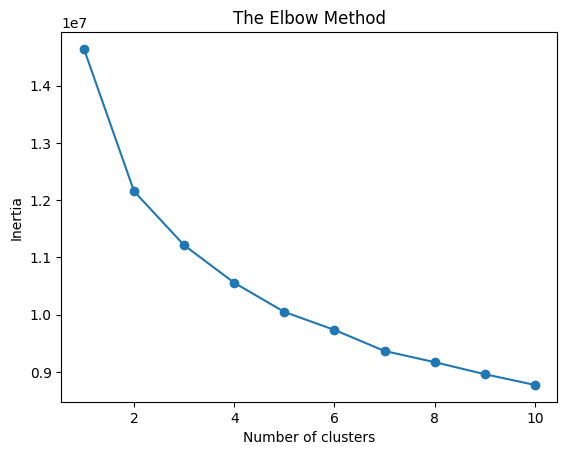

In [ ]:
K_range = range(1, 11)
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
from sklearn import cluster
Kmeans = KMeans(n_clusters=5,random_state=42)
cluster = Kmeans.fit_predict(x)

In [ ]:
df['cluster']=cluster

In [ ]:
df['cluster']

,cluster
0,4
1,1
2,0
3,2
4,4
...,...
999995,1
999996,1
999997,2
999998,1


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(x)

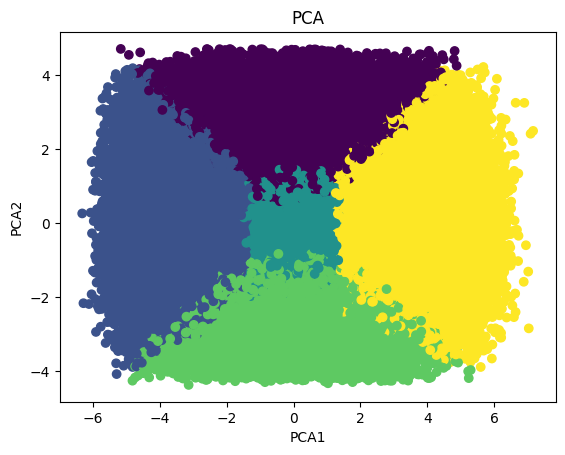

In [ ]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster)
plt.title('PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_avg =  silhouette_score(x, cluster)
print('Silhouette score:', silhouette_avg)